# Rideflow platform prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Guvi_Final_Project\RideFlow_Project/rideflow_datasets.csv")
df.head()

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean


In [10]:
df.tail()

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
49995,382.408307,2025-01-04 23:15:00,Adyar,Porur,12.899931,80.241085,12.835991,80.137516,1107.403326,5258.259532,...,1.009705,3.932942,3.856739,4.065403,16.220926,completed,high,rain,-0.017673,Vehicle was not clean
49996,13.273573,2025-01-01 11:00:00,OMR,OMR,12.935203,80.144480,12.913565,80.235239,1014.870126,6237.886142,...,1.234047,3.627987,3.951893,11.927580,10.847198,cancelled,medium,rain,0.946362,Driver cancelled suddenly
49997,926.129133,2025-01-10 13:00:00,Tambaram,Anna Nagar,13.176039,80.152335,13.023043,80.116558,1513.470801,6971.017870,...,1.196113,3.243434,3.007692,8.240176,8.832941,completed,high,rain,0.019036,Driver was polite
49998,160.054740,2025-01-02 18:45:00,Velachery,Adyar,12.925358,80.121733,12.957550,80.264566,1239.828912,5619.776034,...,1.231227,4.726548,4.602867,6.178889,19.062430,cancelled,low,clear,0.992282,Driver was polite
49999,251.788769,2025-01-03 07:00:00,T Nagar,Tambaram,12.966795,80.112353,12.960161,80.222975,1931.438668,6107.425842,...,1.018007,3.768190,3.145817,6.979756,4.725032,completed,high,cloudy,-0.017331,Driver was polite


In [11]:
df.shape

(50000, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ride_id            50000 non-null  float64
 1   timestamp          50000 non-null  object 
 2   pickup_zone        50000 non-null  object 
 3   drop_zone          50000 non-null  object 
 4   pickup_lat         50000 non-null  float64
 5   pickup_long        50000 non-null  float64
 6   drop_lat           50000 non-null  float64
 7   drop_long          50000 non-null  float64
 8   driver_id          50000 non-null  float64
 9   customer_id        50000 non-null  float64
 10  fare_price         50000 non-null  float64
 11  surge_multiplier   50000 non-null  float64
 12  driver_rating      50000 non-null  float64
 13  customer_rating    50000 non-null  float64
 14  estimated_eta_min  50000 non-null  float64
 15  actual_eta_min     50000 non-null  float64
 16  ride_status        500

In [13]:
df.describe()

,ride_id,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,driver_active
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,502.942430,13.002746,80.199930,12.996655,80.198416,1490.911888,6003.036038,290.173783,1.398791,4.013354,3.984336,11.195109,13.982097,0.495186
std,289.423859,0.116404,0.057921,0.114877,0.057109,286.873863,573.267840,119.053428,0.379386,0.587558,0.571506,4.889879,6.273939,0.500704
min,-38.841291,12.787170,80.093438,12.782913,80.094280,955.351211,4928.914000,67.684311,0.933457,2.916908,2.921773,2.060772,2.098028,-0.096792
25%,251.970959,12.898265,80.152845,12.896173,80.149053,1237.815552,5526.134440,193.115807,1.018201,3.519978,3.489093,7.053015,8.645288,-0.000181
50%,506.575176,13.008076,80.199270,12.994554,80.197927,1484.663349,5993.135524,292.405423,1.221925,4.006790,3.996897,11.002394,14.266847,0.057651
75%,753.842807,13.103020,80.249305,13.095980,80.247298,1733.408447,6508.746928,389.335842,1.527847,4.529103,4.470339,15.617631,19.510386,0.999708
max,1034.516503,13.218218,80.306384,13.212351,80.307531,2041.404760,7063.230521,520.639213,2.071096,5.090861,5.082557,19.835107,24.917300,1.104357


In [14]:
df.describe(include=object)

,timestamp,pickup_zone,drop_zone,ride_status,traffic_level,weather,feedback_text
count,50000,50000,50000,50000,50000,50000,50000
unique,1000,7,7,2,3,3,5
top,2025-01-09 06:15:00,T Nagar,OMR,completed,high,rain,Vehicle was not clean
freq,75,7786,7519,38494,17164,18018,10760


# Data Preprocessing

In [15]:
df.isnull().sum()

ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [18]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['weekday'] = df['timestamp'].dt.weekday
df['is_weekend'] = df['timestamp'].dt.day_name().isin(['Saturday', 'Sunday'])

# EDA

In [13]:
df.head(5)

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,weather,driver_active,feedback_text,date,time,hour,day,month,weekday,is_weekend
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,clear,-0.036560,Driver was polite,2025-01-02,01:30:00,1,2,1,3,False
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,cloudy,0.988999,Driver cancelled suddenly,2025-01-05,12:45:00,12,5,1,6,True
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,rain,0.005750,Driver cancelled suddenly,2025-01-09,23:00:00,23,9,1,3,False
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,clear,1.023604,Good experience,2025-01-03,19:30:00,19,3,1,4,False
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,cloudy,1.016716,Vehicle was not clean,2025-01-02,02:30:00,2,2,1,3,False


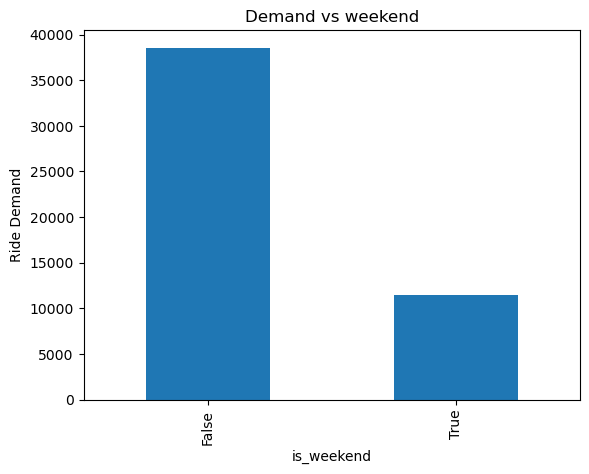

In [19]:
import matplotlib.pyplot as plt
hourly_demand = df.groupby('is_weekend')['ride_id'].count()

plt.figure()
hourly_demand.plot(kind='bar')
plt.xlabel("is_weekend")
plt.ylabel("Ride Demand")
plt.title("Demand vs weekend")
plt.show()

# insight - Ride demand is more consistent and higher on weekdays, possibly due to office commuting patterns.

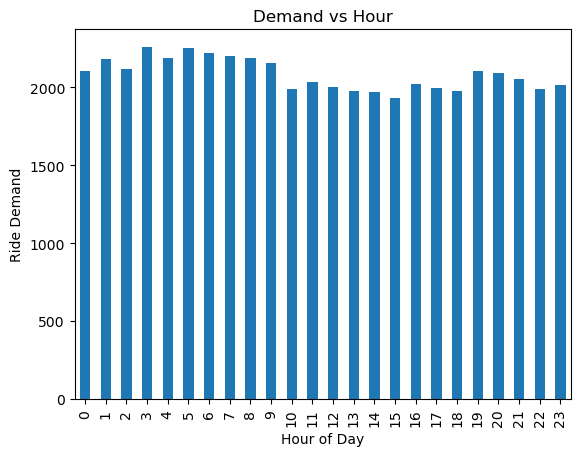

In [16]:
hourly_demand = df.groupby('hour')['ride_id'].count()

plt.figure()
hourly_demand.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Ride Demand")
plt.title("Demand vs Hour")
plt.show()

# insight - The demand follows a time-based pattern with noticeable peaks during commuting hours, which confirms that ride demand is time-dependent.

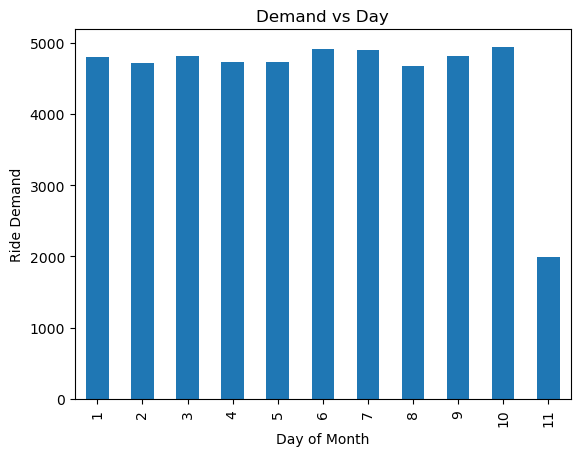

In [20]:
daily_demand = df.groupby('day')['ride_id'].count()

plt.figure()
daily_demand.plot(kind='bar')
plt.xlabel("Day of Month")
plt.ylabel("Ride Demand")
plt.title("Demand vs Day")
plt.show()

# insight - Demand is relatively consistent across days, indicating no extreme seasonal spike within this short time frame,

In [21]:
weather_demand = df.groupby('weather')['ride_id'].count()

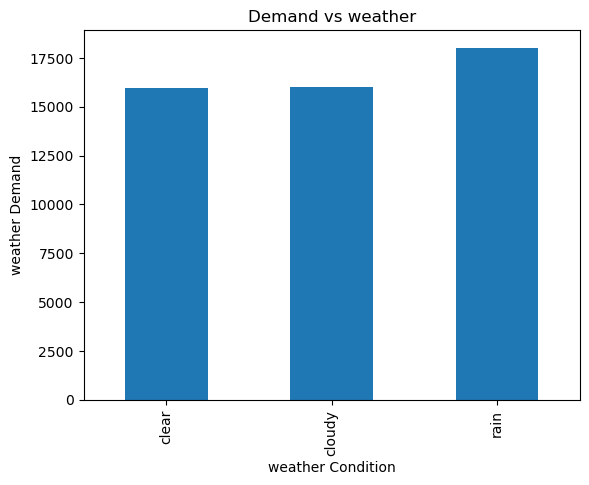

In [22]:
plt.figure()
weather_demand.plot(kind='bar')
plt.xlabel("weather Condition")
plt.ylabel("weather Demand")
plt.title("Demand vs weather")
plt.show()

# insight - Weather has a noticeable impact on ride demand, especially during rain, where customers prefer ride services instead of other transport options.

# Geospatial Encoding

In [23]:
# Encode pickup_zone and drop_zone
from sklearn.preprocessing import LabelEncoder

# Encode weather
le_pickup = LabelEncoder()
le_drop = LabelEncoder()
le_weather = LabelEncoder()
le_traffic = LabelEncoder()
df['pickup_zone_enc'] = le_pickup.fit_transform(df['pickup_zone'])
df['drop_zone_enc'] = le_drop.fit_transform(df['drop_zone'])
df['traffic_level_enc'] = le_traffic.fit_transform(df['traffic_level'])
df['weather_enc'] = le_weather.fit_transform(df['weather'])

# Convert boolean to int
df['is_weekend_int'] = df['is_weekend'].astype(int)


from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['ride_distance_km'] = haversine(df['pickup_lat'], df['pickup_long'], df['drop_lat'], df['drop_long'])
df['eta_delay'] = df['actual_eta_min'] - df['estimated_eta_min']

In [24]:
df.to_csv("rid_enc.csv", index=False)

In [26]:
# -----------------------------------
# Ride Demand Prediction 
# -----------------------------------

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------
# Date & Hour Columns
# -------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['is_weekend_int'] = (df['weekday'] >= 5).astype(int)

# -------------------------
#  Aggregate Demand Per Zone-Date-Hour
# -------------------------
df_demand = df.groupby([
    'pickup_zone_enc',
    'date',
    'hour',
    'weekday',
    'is_weekend_int',
    'weather_enc',
    'traffic_level_enc'
]).agg(
    ride_count=('ride_id', 'count')
).reset_index()

# -------------------------
# Sort Chronologically 
# -------------------------
df_demand = df_demand.sort_values(
    ['pickup_zone_enc', 'date', 'hour']
).reset_index(drop=True)

# -------------------------
# Create Lag Features (Historical Demand)
# -------------------------
df_demand['lag_1'] = df_demand.groupby('pickup_zone_enc')['ride_count'].shift(1)
df_demand['lag_2'] = df_demand.groupby('pickup_zone_enc')['ride_count'].shift(2)
df_demand['lag_24'] = df_demand.groupby('pickup_zone_enc')['ride_count'].shift(24)

# -------------------------
#  Rolling Mean Feature
# -------------------------
df_demand['rolling_mean_3'] = (
    df_demand.groupby('pickup_zone_enc')['ride_count']
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

# -------------------------
#  Drop Rows with NaN (due to lag creation)
# -------------------------
df_demand = df_demand.dropna().reset_index(drop=True)

# -------------------------
# Features & Target
# -------------------------
demand_features = [
    'pickup_zone_enc',
    'hour',
    'weekday',
    'is_weekend_int',
    'weather_enc',
    'traffic_level_enc',
    'lag_1',
    'lag_2',
    'lag_24',
    'rolling_mean_3'
]

X_demand = df_demand[demand_features]
y_demand = df_demand['ride_count']

# -------------------------
# Time-Based Train-Test Split (NO SHUFFLE)
# -------------------------
split_index = int(len(df_demand) * 0.8)

X_train_d = X_demand.iloc[:split_index]
X_test_d  = X_demand.iloc[split_index:]

y_train_d = y_demand.iloc[:split_index]
y_test_d  = y_demand.iloc[split_index:]

# -------------------------
#  Train Model
# -------------------------
demand_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

demand_model.fit(X_train_d, y_train_d)

# -------------------------
#  Evaluate Model
# -------------------------
y_pred_d = demand_model.predict(X_test_d)

rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d))
r2_d = r2_score(y_test_d, y_pred_d)

print(f"Demand Prediction → RMSE: {rmse_d:.2f}")
print(f"Demand Prediction → R2: {r2_d:.4f}")

# -------------------------
#  Predict On Full Dataset
# -------------------------
df_demand['predicted_demand'] = demand_model.predict(X_demand)

Demand Prediction → RMSE: 1.53
Demand Prediction → R2: 0.9915


In [27]:
import pickle

with open("demand_features.pkl", "wb") as f:
    pickle.dump(demand_features, f)

In [29]:
from sklearn.metrics import mean_absolute_error
# -------------------------
#  Driver Supply Prediction
# -------------------------

# Aggregate driver availability
df_supply = df.groupby(
    ['pickup_zone_enc','date','hour','weekday','is_weekend_int','weather_enc','traffic_level_enc']
).agg(
    available_drivers=('driver_id','nunique')
).reset_index()

# Sort chronologically
df_supply = df_supply.sort_values(['pickup_zone_enc','date','hour'])

# -------------------------
# Add Lag Features
# -------------------------
df_supply['lag_1'] = df_supply.groupby('pickup_zone_enc')['available_drivers'].shift(1)
df_supply['lag_2'] = df_supply.groupby('pickup_zone_enc')['available_drivers'].shift(2)
df_supply['lag_24'] = df_supply.groupby('pickup_zone_enc')['available_drivers'].shift(24)

# Rolling mean
df_supply['rolling_mean_3'] = (
    df_supply.groupby('pickup_zone_enc')['available_drivers']
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

# Drop NA rows from lagging
df_supply = df_supply.dropna()

# -------------------------
# Features & Target
# -------------------------
features_supply = [
    'pickup_zone_enc','hour','weekday','is_weekend_int',
    'weather_enc','traffic_level_enc',
    'lag_1','lag_2','lag_24','rolling_mean_3'
]

X_supply = df_supply[features_supply]
y_supply = df_supply['available_drivers']

# -------------------------
# Time-Based Split (No Leakage)
# -------------------------
split_index = int(len(df_supply) * 0.8)

X_train_s = X_supply.iloc[:split_index]
X_test_s = X_supply.iloc[split_index:]

y_train_s = y_supply.iloc[:split_index]
y_test_s = y_supply.iloc[split_index:]

# -------------------------
# Train Model
# -------------------------
supply_model = RandomForestRegressor(n_estimators=100, random_state=42)
supply_model.fit(X_train_s, y_train_s)

# Predict
y_pred_s = supply_model.predict(X_test_s)

# Metrics
mae_s = mean_absolute_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("Supply MAE:", mae_s)
print("Supply R2:", r2_s)

df_supply['predicted_supply'] = supply_model.predict(X_supply)

Supply MAE: 0.4399158249158249
Supply R2: 0.9910459548974853


In [30]:
import pickle

with open("features_supply.pkl", "wb") as f:
    pickle.dump(features_supply, f)

In [31]:
# -------------------------
#  Merge Demand & Supply for Gap & Surge
# -------------------------
df_phase2 = df_demand.merge(
    df_supply[['pickup_zone_enc','date','hour','predicted_supply']],
    on=['pickup_zone_enc','date','hour'],
    how='left'
)

# Compute demand-supply gap
df_phase2['demand_supply_gap'] = (
    df_phase2['predicted_demand'] - df_phase2['predicted_supply']
)

df_phase2['gap_ratio'] = (
    df_phase2['demand_supply_gap'] / df_phase2['predicted_supply']
)
df_phase2['surge_multiplier'] = (
    1 + df_phase2['gap_ratio'].clip(lower=0) * 0.4
).clip(1.0, 3.0)


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
# -----------------------------
# Cancellation Prediction
# -----------------------------

# Reduce df_phase2 size
df_surge = df_phase2[['pickup_zone_enc','date','hour','surge_multiplier']].copy()

df_surge = df_surge.drop_duplicates(
    subset=['pickup_zone_enc','date','hour']
)

# Convert to smaller types
df_surge['pickup_zone_enc'] = df_surge['pickup_zone_enc'].astype('int16')
df_surge['hour'] = df_surge['hour'].astype('int8')
df_surge['surge_multiplier'] = df_surge['surge_multiplier'].astype('float32')

# Copy original df (reduce memory)
df_cancel = df[[
    'pickup_zone_enc',
    'date',
    'hour',
    'eta_delay',
    'traffic_level_enc',
    'weather_enc',
    'ride_distance_km',
    'ride_status'
]].copy()

# Convert numeric columns to float32
df_cancel['eta_delay'] = df_cancel['eta_delay'].astype('float32')
df_cancel['ride_distance_km'] = df_cancel['ride_distance_km'].astype('float32')

#  Merge safely
df_cancel = df_cancel.merge(
    df_surge,
    on=['pickup_zone_enc','date','hour'],
    how='left'
)

#  Fill missing surge
df_cancel['surge_multiplier'] = df_cancel['surge_multiplier'].fillna(1.0).astype('float32')

# -----------------------------
# Model Training
# -----------------------------

features_cancel = [
    'eta_delay',
    'traffic_level_enc',
    'weather_enc',
    'ride_distance_km',
    'surge_multiplier'
]

X_cancel = df_cancel[features_cancel]
y_cancel = df_cancel['ride_status']

# Time-based split (correct for ML)
split_index = int(len(df_cancel) * 0.8)

X_train_c = X_cancel.iloc[:split_index]
X_test_c  = X_cancel.iloc[split_index:]

y_train_c = y_cancel.iloc[:split_index]
y_test_c  = y_cancel.iloc[split_index:]

# Smaller forest to reduce memory
cancel_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42
)

cancel_model.fit(X_train_c, y_train_c)

# Predict only on test set (not full data!)
y_pred_prob = cancel_model.predict_proba(X_test_c)[:,1]

auc = roc_auc_score(y_test_c, y_pred_prob)

print("Cancellation AUC:", auc)

Cancellation AUC: 0.9206004687767656


In [36]:
import pickle

with open("features_cancel.pkl", "wb") as f:
    pickle.dump(features_cancel, f)

In [37]:
df_cancel['predicted_cancellation_prob'] = cancel_model.predict_proba(X_cancel)[:,1]

In [38]:
df_phase2_clean = (
    df_phase2
    .groupby(['pickup_zone_enc','date','hour'])
    .agg({
        'predicted_demand': 'mean',
        'predicted_supply': 'mean',
        'demand_supply_gap': 'mean',
        'surge_multiplier': 'mean'
    })
    .reset_index()
)

In [39]:
system_intelligence = df_phase2_clean.copy()

cancel_agg = (
    df_cancel
    .groupby(['pickup_zone_enc','date','hour'])['predicted_cancellation_prob']
    .mean()
    .reset_index()
)

system_intelligence = system_intelligence.merge(
    cancel_agg,
    on=['pickup_zone_enc','date','hour'],
    how='left'
)

system_intelligence['predicted_cancellation_prob'] = \
    system_intelligence['predicted_cancellation_prob'].fillna(0)

In [40]:
system_intelligence.head()

,pickup_zone_enc,date,hour,predicted_demand,predicted_supply,demand_supply_gap,surge_multiplier,predicted_cancellation_prob
0,0,2025-01-01,7,14.971667,14.980000,-0.008333,1.449916,0.903528
1,0,2025-01-01,8,1.000000,1.000000,0.000000,1.000000,0.879480
2,0,2025-01-01,9,1.000000,1.000000,0.000000,1.000000,0.459723
3,0,2025-01-01,10,17.876250,17.711250,0.165000,1.547200,0.782003
4,0,2025-01-01,11,1.163333,1.173333,-0.010000,1.026820,0.540305


In [41]:
import joblib

# Save models
system_model = {
    "demand_model": demand_model,
    "supply_model": supply_model,
    "cancel_model": cancel_model
}

joblib.dump(system_model, "rideflow_system.pkl")
print("Models saved successfully")

Models saved successfully
